In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, optimizers
from tensorflow.keras.layers import Dense, InputLayer, BatchNormalization, Activation, Dropout, LSTM, Flatten, Reshape
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

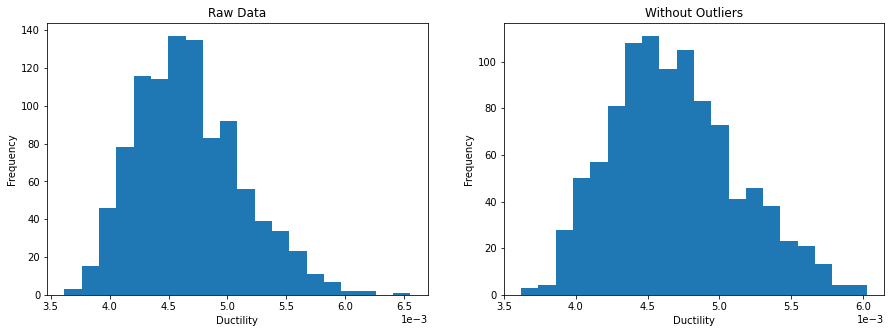

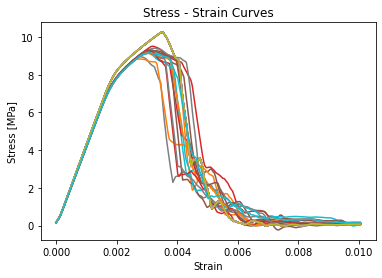

In [15]:
%run DataProcessing.ipynb

In [16]:
# assert not np.any(np.isnan(train_in))

In [17]:
def build_model(inputs, outputs, layers, act='relu', verbose=0):
    model = Sequential(name='FCNN')

    model.add(InputLayer(input_shape=(1, len(inputs[0][0]))))
    model.add(BatchNormalization())

    model.add(Dense(layers[0]))
    model.add(BatchNormalization())
    model.add(Activation(act))
    
    for i, n in enumerate(layers[1:]):
        i = i + 1
        model.add(Reshape((1, layers[i-1])))
        model.add(LSTM(n, return_sequences=True, input_shape=(1, layers[i-1])))
        model.add(Dense(n))
        model.add(BatchNormalization())
        model.add(Activation(act))

    model.add(Dense(len(outputs[0][0])))
    
    OPT = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    METS = ['ACC', 'MAE', 'MSE']
    model.compile(optimizer=OPT, loss='MSE', metrics=METS)  # , loss_weights=[1,2])

    if verbose == 1:
        print(model.summary())
    
    return model


def train_model(model, train_in, train_out, EPOCHS=100, BATCH=16, callbacks=None, verbose=0):
    early_stop = EarlyStopping(monitor='val_loss', patience=25, verbose=verbose, mode='min')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=18, verbose=verbose,
                                  min_delta=1e-4, mode='min')
    if callbacks:
        callbacks = [reduce_lr , early_stop]

    fitHistory = model.fit(train_in, train_out, epochs=EPOCHS, batch_size=BATCH, validation_split=0.2, verbose=verbose, 
                           callbacks=callbacks)  #, sample_weight=weights)

    fitHistory_df = pd.DataFrame(fitHistory.history)

    return fitHistory, fitHistory_df

In [24]:
model = build_model(inputs=train_in, 
                    outputs=train_out,
                    verbose=0,
                    layers=[2048, 1024, 1024, 512, 512, 256], 
                    act='sigmoid') 

fitHistory, fitHistory_df = train_model(model=model, 
                                        train_in=train_in, 
                                        train_out=train_out, 
                                        EPOCHS=100, 
                                        BATCH=16, 
                                        callbacks=True,
                                        verbose=0) # overfitting? Try dropout

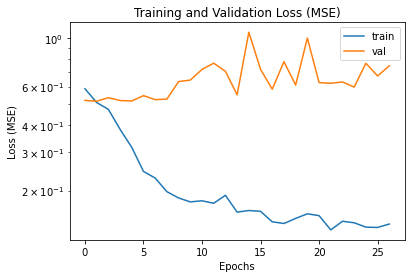

In [25]:
def plot_training(fitHistory):
    fig1, ax1 = plt.subplots()
    
    ax1.set_title("Training and Validation Loss (MSE)")
    ax1.plot(list(fitHistory.history.values())[0], label='train')
    ax1.plot(list(fitHistory.history.values())[4], label='val')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_xlabel('Epochs')
    ax1.legend()
    ax1.set_yscale('log')
    
    plt.show()

plot_training(fitHistory)

In [26]:
def evaluate(model, fitHistory_df, train_in, train_out, test_in, test_out, BATCH=16):
    trainEv = model.evaluate(train_in, train_out, batch_size=BATCH)
    testEv = model.evaluate(test_in, test_out, batch_size=BATCH)

    ev_df = pd.DataFrame(columns=list(fitHistory_df.columns[:4]))
    ev_df.loc[0] = trainEv
    ev_df.loc[1] = testEv

    return trainEv, testEv, ev_df


def predict_model(model, test_in, test_out):#, test_df):
    pred = model.predict(test_in)
    
    MSE_all = mean_squared_error(test_out, pred)
    MAE_all = mean_absolute_error(test_out, pred)
    
    MSE_byStrain = np.array([[(tt - pp)**2 for tt, pp in zip(t, p)] for t, p in zip(test_out, pred)])
    MAE_byStrain = np.array([[abs(tt - pp) for tt, pp in zip(t, p)] for t, p in zip(test_out, pred)])
    
    Pmets = [MSE_all, MAE_all, MSE_byStrain, MAE_byStrain]

#     output_df = test_df.copy()
#     output_df = output_df.drop(columns=['x', 'y_up', 'y_low'])
#     output_df['LtD'] = ldt
#     output_df['Cl_pred'] = clp
#     output_df['Cd_pred'] = cdp
#     output_df['LtD_pred'] = ldp

    return pred, Pmets #, output_df

In [27]:
# trainEv, testEv, ev_df = evaluate(model=model, 
#                                   fitHistory_df=fitHistory_df, 
#                                   train_in=train_in, 
#                                   train_out=train_out, 
#                                   test_in=test_in, 
#                                   test_out=test_out, 
#                                   BATCH=16)

pred, Pmets = predict_model(model=model,
                            test_in=test_in, 
                            test_out=test_out)

5/5 [==============================] - 1s 23ms/step


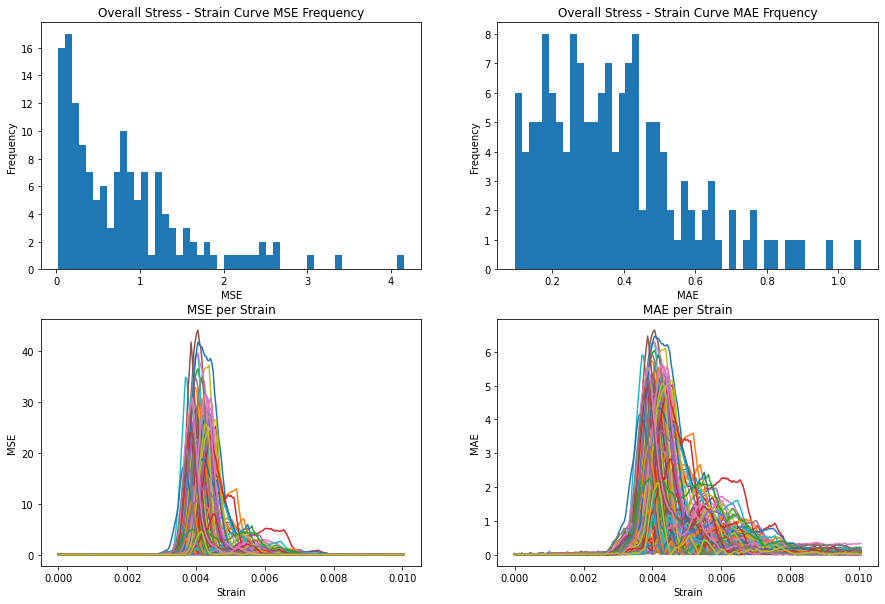

In [28]:
def plot_mets(mets, xOUT):
    fig2, axs = plt.subplots(2, 2)
    fig2.set_figheight(10)
    fig2.set_figwidth(15)
    
    axs[0,0].set_title("Overall Stress - Strain Curve MSE Frequency")
    axs[0,0].hist([float(i[0]) for i in mets[0]], bins=50)
    axs[0,0].set_ylabel('Frequency')
    axs[0,0].set_xlabel('MSE')
    
    axs[0,1].set_title("Overall Stress - Strain Curve MAE Frquency")
    axs[0,1].hist([float(i[0]) for i in mets[1]], bins=50)
    axs[0,1].set_ylabel('Frequency')
    axs[0,1].set_xlabel('MAE')
    
    axs[1,0].set_title("MSE per Strain")
    for i in mets[2]:
        axs[1,0].plot(xOUT, i[0])
    axs[1,0].set_ylabel('MSE')
    axs[1,0].set_xlabel('Strain')
    
    axs[1,1].set_title("MAE per Strain")
    for i in mets[3]:
        axs[1,1].plot(xOUT, i[0])
    axs[1,1].set_ylabel('MAE')
    axs[1,1].set_xlabel('Strain')
    
    plt.show()

plot_mets(Pmets, xOUT)

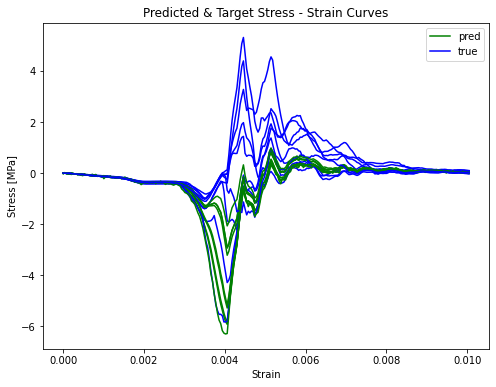

In [29]:
def plot_pred(pred, test_out, xOUT, q=10, idx=None):
    fig3, ax1 = plt.subplots()
    fig3.set_figheight(6)
    fig3.set_figwidth(8)
    
    ax1.set_title("Predicted & Target Stress - Strain Curves")
    ax1.set_ylabel('Stress [MPa]')
    ax1.set_xlabel('Strain')
    
    if idx is not None:
        ax1.plot(xOUT, pred[idx][0], color='g', label='pred')
        ax1.plot(xOUT, test_out[idx][0], color='b', label='true')
    
    else:
        idxs = list(set([random.randint(0, len(pred)) for i in range(q)]))
        for p, t in zip(pred[idxs], test_out[idxs]):
            ax1.plot(xOUT, p[0], color='g')
            ax1.plot(xOUT, t[0], color='b')
    
    ax1.legend(['pred', 'true'])
    plt.show()

plot_pred(pred, test_out, xOUT, q=10, idx=None)

Custom Loss